# 01 - Preprocessing & Feature Engineering
**Kompetisi:** INFEST XII 2026 - Data Science (Klasifikasi Aksara Tradisional Nusantara)
**Tim:** Fadhil - Percobaan 1

Notebook ini melanjutkan temuan dari `00_data_exploration.ipynb`. Ringkasan temuan yang jadi dasar
keputusan di notebook ini:

- 7 kelas, imbalance moderat (rasio 2.24x, bali/lontara paling sedikit)
- 1 file corrupt (`mPmaODVU.png`) — perlu di-drop
- Aspect ratio gambar sangat bervariasi (banyak strip teks memanjang, bukan citra persegi)
- Dataset campuran cetak & tulisan tangan, beberapa kelas (jawi vs pegon) punya kemiripan visual
- Ditemukan indikasi potensi mislabel di kelas `jawi`

**Isi notebook:**
1. Setup & Load Data (Clean)
2. Data Cleaning (Drop Corrupt File)
3. Stratified Train/Validation Split
4. Image Preprocessing Pipeline (Resize + Padding, Normalisasi)
5. Augmentasi Data (Terarah untuk Kelas Minoritas)
6. Class Weighting untuk Loss Function
7. Verifikasi Pipeline (Sanity Check Visual)
8. Simpan Artefak untuk Tahap Modeling


## 1. Setup & Load Data (Clean)

In [25]:
import os
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = "../dataset"
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TRAIN_IMG_DIR = os.path.join(DATA_DIR, "images", "train")

ARTIFACT_DIR = "../artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

train_df = pd.read_csv(TRAIN_CSV)
print("Train shape awal:", train_df.shape)
train_df.head()


Train shape awal: (4468, 2)


,image_id,label
0,SxrIaKaJ.png,pegon
1,XiR75p4l.png,jawi
2,gpadO4eH.png,jawa
3,IlL62jcp.png,lampung
4,7bEtcJPy.png,bali


## 2. Data Cleaning (Drop Corrupt File)

Ditemukan 1 file corrupt (`mPmaODVU.png`) pada tahap eksplorasi. Drop baris ini dari train set
sebelum lanjut ke split dan training. Idealnya jalankan ulang pengecekan corrupt di sini secara
otomatis (bukan hardcode) supaya notebook tetap valid kalau dataset berubah.

In [26]:
def find_corrupt_images(df, img_dir):
    corrupt = []
    for img_id in df['image_id']:
        img_path = os.path.join(img_dir, img_id)
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception as e:
            corrupt.append(img_id)
    return corrupt

corrupt_files = find_corrupt_images(train_df, TRAIN_IMG_DIR)
print(f"File corrupt ditemukan: {corrupt_files}")

train_df_clean = train_df[~train_df['image_id'].isin(corrupt_files)].reset_index(drop=True)
print(f"Train set sebelum: {len(train_df)}, sesudah drop corrupt: {len(train_df_clean)}")


File corrupt ditemukan: ['mPmaODVU.png']
Train set sebelum: 4468, sesudah drop corrupt: 4467


In [27]:
# Cek ulang distribusi kelas setelah cleaning, pastikan tidak timpang jauh dari sebelumnya
print(train_df_clean['label'].value_counts().sort_values(ascending=False))


label
lampung    822
jawi       814
pegon      771
sunda      658
jawa       653
lontara    382
bali       367
Name: count, dtype: int64


## 3. Stratified Train/Validation Split

Karena metrik lomba adalah F1-Score Macro dan dataset imbalance (2.24x), split harus **stratified**
agar proporsi ke-7 kelas terjaga sama antara train dan validation set. Validation set dipakai untuk
evaluasi jujur sebelum submit ke Kaggle (Public Score).

In [28]:
VAL_SIZE = 0.15  # 15% untuk validation

train_split_df, val_split_df = train_test_split(
    train_df_clean,
    test_size=VAL_SIZE,
    stratify=train_df_clean['label'],
    random_state=SEED
)

train_split_df = train_split_df.reset_index(drop=True)
val_split_df = val_split_df.reset_index(drop=True)

print(f"Train split: {len(train_split_df)} sampel")
print(f"Val split  : {len(val_split_df)} sampel")


Train split: 3796 sampel
Val split  : 671 sampel


In [29]:
# Verifikasi proporsi kelas tetap konsisten di kedua split
comparison = pd.DataFrame({
    "train_pct": train_split_df['label'].value_counts(normalize=True).sort_index() * 100,
    "val_pct": val_split_df['label'].value_counts(normalize=True).sort_index() * 100
})
comparison.round(2)


,train_pct,val_pct
label,,
bali,8.22,8.20
jawa,14.62,14.61
jawi,18.23,18.18
lampung,18.39,18.48
lontara,8.56,8.49
pegon,17.26,17.29
sunda,14.73,14.75


## 4. Image Preprocessing Pipeline (Resize + Padding, Normalisasi)

Temuan penting dari eksplorasi: aspect ratio gambar **sangat bervariasi** (banyak strip teks
memanjang, ada juga yang mendekati persegi). Resize langsung ke ukuran persegi (misal stretch ke
224x224) akan mendistorsi bentuk karakter.

**Strategi yang dipakai:** resize dengan mempertahankan aspect ratio (fit ke sisi terpanjang),
lalu padding warna putih di sisi yang kurang (letterbox) supaya hasil akhir tetap persegi tanpa
distorsi bentuk aksara.

In [30]:
TARGET_SIZE = (224, 224)  # sesuaikan dengan arsitektur model yang dipakai nanti

def resize_with_padding(img, target_size=TARGET_SIZE, fill_color=(255, 255, 255)):
    """Resize gambar menjaga aspect ratio, lalu padding ke ukuran target (letterbox)."""
    img = img.convert("RGB")
    original_w, original_h = img.size
    target_w, target_h = target_size

    ratio = min(target_w / original_w, target_h / original_h)
    new_w, new_h = int(original_w * ratio), int(original_h * ratio)

    img_resized = img.resize((new_w, new_h), Image.LANCZOS)

    new_img = Image.new("RGB", target_size, fill_color)
    paste_x = (target_w - new_w) // 2
    paste_y = (target_h - new_h) // 2
    new_img.paste(img_resized, (paste_x, paste_y))

    return new_img

def preprocess_image(img_path, target_size=TARGET_SIZE, normalize=True):
    img = Image.open(img_path)
    img = resize_with_padding(img, target_size)
    arr = np.array(img).astype(np.float32)
    if normalize:
        arr = arr / 255.0
    return arr


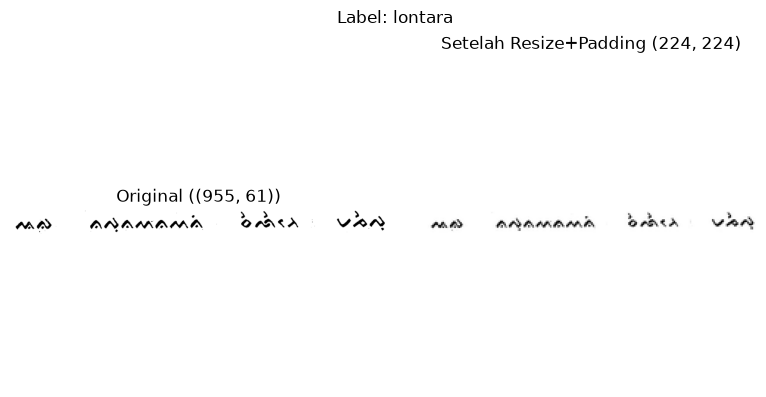

In [31]:
# Quick test pipeline pada 1 gambar
sample_path = os.path.join(TRAIN_IMG_DIR, train_split_df.iloc[0]['image_id'])
sample_label = train_split_df.iloc[0]['label']

original_img = Image.open(sample_path)
processed_arr = preprocess_image(sample_path)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(original_img, cmap='gray' if original_img.mode == 'L' else None)
axes[0].set_title(f"Original ({original_img.size})")
axes[0].axis('off')

axes[1].imshow(processed_arr)
axes[1].set_title(f"Setelah Resize+Padding {TARGET_SIZE}")
axes[1].axis('off')

plt.suptitle(f"Label: {sample_label}")
plt.tight_layout()
plt.show()


## 5. Augmentasi Data (Terarah untuk Kelas Minoritas)

Karena imbalance moderat (lampung 823 vs bali 367), augmentasi diarahkan lebih agresif ke kelas
minoritas (`bali`, `lontara`) untuk memperbanyak variasi data secara efektif tanpa duplikasi murni.

**Catatan penting untuk data aksara:** hindari augmentasi yang bisa mengubah makna/bentuk karakter
secara signifikan:
- Rotasi **dibatasi kecil** (misal ±5-10 derajat), rotasi besar bisa membuat aksara sulit dikenali
  bahkan oleh manusia
- **Hindari horizontal flip** — banyak aksara punya orientasi/arah baca yang bermakna, flip bisa
  mengubah karakter jadi tidak valid
- Fokus ke augmentasi yang aman: sedikit noise, slight brightness/contrast, sedikit shift/translate,
  slight zoom

In [32]:
import torchvision.transforms as T

MINORITY_CLASSES = ["bali", "lontara"]  # sesuaikan berdasarkan hasil distribusi kelas

# Color jitter SERAGAM untuk semua kelas — brightness/contrast tidak boleh jadi shortcut
# yang membedakan kelas minoritas vs mayoritas
color_jitter = T.ColorJitter(brightness=0.1, contrast=0.1)

# Spasial ringan untuk kelas mayoritas
light_spatial = T.Compose([
    T.RandomRotation(degrees=5, fill=255),
    T.RandomAffine(degrees=0, translate=(0.02, 0.02), fill=255),
])

# Spasial lebih agresif untuk kelas minoritas (bali, lontara)
strong_spatial = T.Compose([
    T.RandomRotation(degrees=8, fill=255),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05), fill=255),
])

light_augment = T.Compose([light_spatial, color_jitter])
strong_augment = T.Compose([strong_spatial, color_jitter])

def get_augmentation_for_class(label):
    return strong_augment if label in MINORITY_CLASSES else light_augment

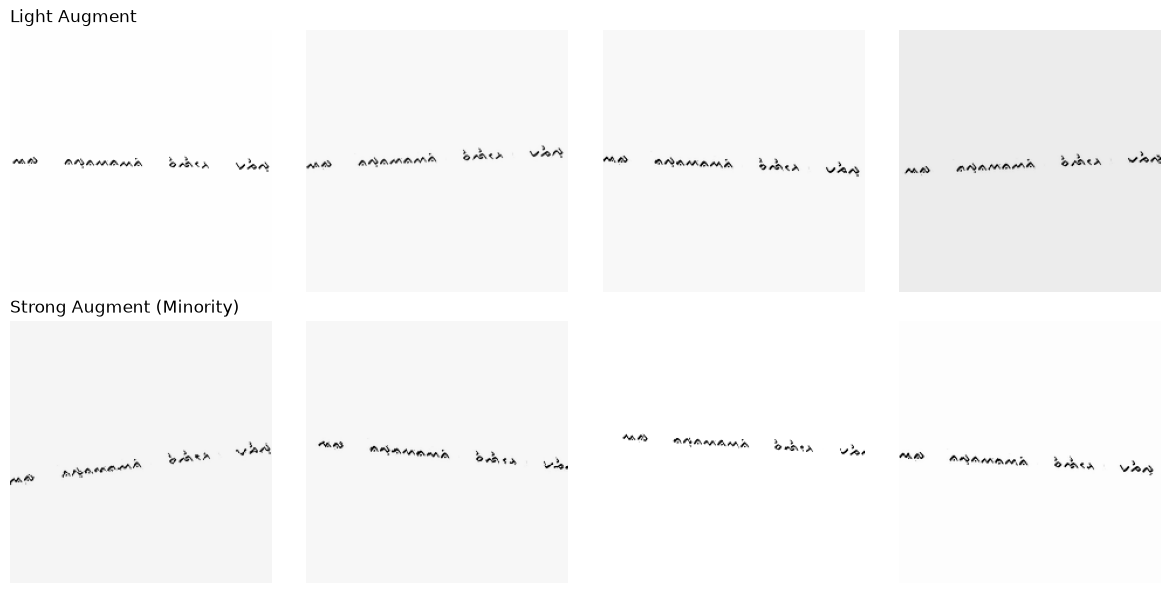

In [33]:
# Sanity check visual: bandingkan hasil augmentasi ringan vs agresif pada 1 sample
sample_path = os.path.join(TRAIN_IMG_DIR, train_split_df.iloc[0]['image_id'])
base_img = resize_with_padding(Image.open(sample_path))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    axes[0, i].imshow(light_augment(base_img))
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title("Light Augment", loc='left')

for i in range(4):
    axes[1, i].imshow(strong_augment(base_img))
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title("Strong Augment (Minority)", loc='left')

plt.tight_layout()
plt.show()


## 6. Class Weighting untuk Loss Function

Sebagai pelengkap augmentasi terarah, hitung class weight berdasarkan inverse frequency untuk
dipakai di loss function (misal `CrossEntropyLoss(weight=...)` di PyTorch atau
`class_weight` di Keras). Ini memberi penalti lebih besar saat model salah memprediksi kelas
minoritas.

In [34]:
classes_sorted = sorted(train_split_df['label'].unique())
label_to_idx = {label: idx for idx, label in enumerate(classes_sorted)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

y_train_idx = train_split_df['label'].map(label_to_idx).values

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(classes_sorted)),
    y=y_train_idx
)

class_weight_dict = {idx_to_label[i]: round(w, 3) for i, w in enumerate(class_weights_array)}
print("Class weights (balanced):")
for label, w in sorted(class_weight_dict.items(), key=lambda x: -x[1]):
    print(f"  {label:10s}: {w}")


Class weights (balanced):
  bali      : 1.738
  lontara   : 1.669
  jawa      : 0.977
  sunda     : 0.97
  pegon     : 0.828
  jawi      : 0.784
  lampung   : 0.777


> **Catatan:** kelas dengan sampel lebih sedikit (`bali`, `lontara`) otomatis mendapat weight lebih
> besar. Weight ini akan dipakai saat inisialisasi loss function di `02_modeling.ipynb`, contoh:
> ```python
> weights_tensor = torch.tensor([class_weight_dict[c] for c in classes_sorted], dtype=torch.float32)
> criterion = nn.CrossEntropyLoss(weight=weights_tensor)
> ```

## 7. Verifikasi Pipeline (Sanity Check Visual)

Sebelum lanjut ke modeling, cek ulang bahwa pipeline preprocessing + augmentasi berjalan konsisten
untuk seluruh kelas — tidak ada kelas yang gambar hasil akhirnya rusak/terlalu terdistorsi.

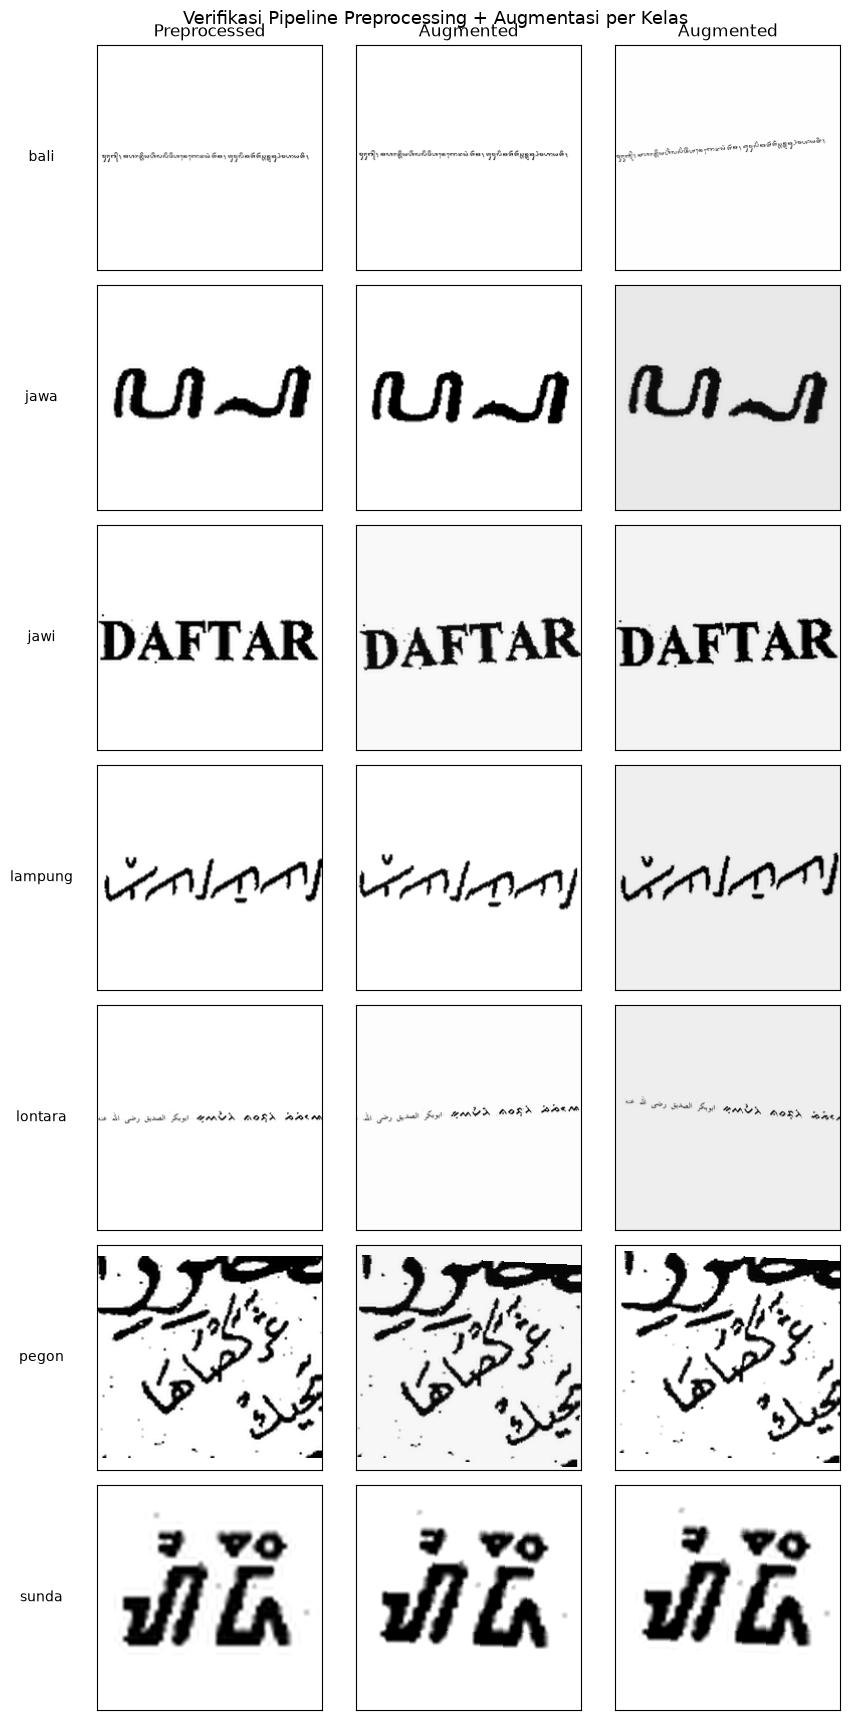

In [35]:
fig, axes = plt.subplots(len(classes_sorted), 3, figsize=(9, len(classes_sorted) * 2.5))

for i, cls in enumerate(classes_sorted):
    sample_row = train_split_df[train_split_df['label'] == cls].sample(1, random_state=SEED).iloc[0]
    img_path = os.path.join(TRAIN_IMG_DIR, sample_row['image_id'])
    base_img = resize_with_padding(Image.open(img_path))
    aug_fn = get_augmentation_for_class(cls)

    axes[i, 0].imshow(base_img)
    axes[i, 0].set_ylabel(cls, fontsize=10, rotation=0, labelpad=40, va='center')
    axes[i, 0].set_title("Preprocessed" if i == 0 else "")
    axes[i, 0].set_xticks([]); axes[i, 0].set_yticks([])

    for j in range(1, 3):
        axes[i, j].imshow(aug_fn(base_img))
        axes[i, j].set_title("Augmented" if i == 0 else "")
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])

plt.suptitle("Verifikasi Pipeline Preprocessing + Augmentasi per Kelas", fontsize=13)
plt.tight_layout()
plt.show()


> **Catatan interpretasi (isi manual):**
> - Apakah hasil augmentasi masih terlihat sebagai aksara yang valid (tidak rusak/tidak terbaca)?
> - Apakah padding letterbox membuat karakter terlalu kecil di tengah gambar untuk kelas dengan
>   aspect ratio ekstrem?
> - Perlu adjustment TARGET_SIZE atau parameter augmentasi?

## 8. Simpan Artefak untuk Tahap Modeling

Simpan hasil split dan konfigurasi ke folder `artifacts/` supaya notebook modeling
(`02_modeling.ipynb`) tinggal load, tidak perlu ulangi proses cleaning & split dari awal
(menjaga konsistensi & reproduksibilitas).

In [36]:
train_split_df.to_csv(os.path.join(ARTIFACT_DIR, "train_split.csv"), index=False)
val_split_df.to_csv(os.path.join(ARTIFACT_DIR, "val_split.csv"), index=False)

config = {
    "seed": SEED,
    "target_size": TARGET_SIZE,
    "val_size": VAL_SIZE,
    "classes": classes_sorted,
    "label_to_idx": label_to_idx,
    "minority_classes": MINORITY_CLASSES,
    "class_weights": class_weight_dict,
    "corrupt_files_dropped": corrupt_files,
}

with open(os.path.join(ARTIFACT_DIR, "preprocessing_config.json"), "w") as f:
    json.dump(config, f, indent=2)

print("Artefak tersimpan di:", ARTIFACT_DIR)
print(os.listdir(ARTIFACT_DIR))


Artefak tersimpan di: ../artifacts
['preprocessing_config.json', 'train_split.csv', 'val_split.csv']


### Ringkasan Keputusan Preprocessing (untuk laporan/notebook final)

- **Cleaning:** drop 1 file corrupt (`mPmaODVU.png`)
- **Split:** stratified train/val (85/15) agar proporsi 7 kelas terjaga
- **Resize:** letterbox (resize + padding) ke `TARGET_SIZE`, menjaga aspect ratio asli tanpa distorsi
- **Augmentasi:** ringan untuk kelas mayoritas, lebih agresif untuk kelas minoritas (`bali`, `lontara`);
  rotasi dibatasi kecil dan **tanpa horizontal flip** karena orientasi aksara bermakna
- **Class weighting:** balanced weight dihitung dari inverse frequency, dipakai di loss function
  tahap modeling

**Lanjut ke:** `02_modeling.ipynb` — load `train_split.csv`, `val_split.csv`, dan
`preprocessing_config.json` dari `artifacts/`.